- This Notebook Generates the **model summary** of **all models** in each run (from the experiments' json files) and creates **bar plots** and **heatmaps** for comparison

In [28]:
import json
from pathlib import Path

run_number = 11
# OUTPUT Folder Paths
PROJECT_ROOT = Path.cwd()
EXPERIMENTS_DIR = PROJECT_ROOT / "experiments"
RESULTS_DIR = PROJECT_ROOT / "results" / f"run{run_number}"

metrics_file = EXPERIMENTS_DIR / f"metrics_run{run_number}.json"

# Step 1: Load JSON file
with open(metrics_file, "r") as file:
    metrics = json.load(file)

acc_1 = metrics["VQC-Model-1"]["evaluation_metrics"]["accuracy"]
prec_1 = metrics["VQC-Model-1"]["evaluation_metrics"]["precision"]
rec_1 = metrics["VQC-Model-1"]["evaluation_metrics"]["recall"]
f1_1 = metrics["VQC-Model-1"]["evaluation_metrics"]["f1_score"]

acc_2 = metrics["VQC-Model-2"]["evaluation_metrics"]["accuracy"]
prec_2 = metrics["VQC-Model-2"]["evaluation_metrics"]["precision"]
rec_2 = metrics["VQC-Model-2"]["evaluation_metrics"]["recall"]
f1_2 = metrics["VQC-Model-2"]["evaluation_metrics"]["f1_score"]

acc_3 = metrics["VQC-Model-3"]["evaluation_metrics"]["accuracy"]
prec_3 = metrics["VQC-Model-3"]["evaluation_metrics"]["precision"]
rec_3 = metrics["VQC-Model-3"]["evaluation_metrics"]["recall"]
f1_3 = metrics["VQC-Model-3"]["evaluation_metrics"]["f1_score"]

acc_4 = metrics["VQC-Model-4"]["evaluation_metrics"]["accuracy"]
prec_4 = metrics["VQC-Model-4"]["evaluation_metrics"]["precision"]
rec_4 = metrics["VQC-Model-4"]["evaluation_metrics"]["recall"]
f1_4 = metrics["VQC-Model-4"]["evaluation_metrics"]["f1_score"]

acc_svm = metrics["SVM"]["evaluation_metrics"]["accuracy"]
prec_svm = metrics["SVM"]["evaluation_metrics"]["precision"]
rec_svm = metrics["SVM"]["evaluation_metrics"]["recall"]
f1_svm = metrics["SVM"]["evaluation_metrics"]["f1_score"]

acc_rf = metrics["RF"]["evaluation_metrics"]["accuracy"]
prec_rf = metrics["RF"]["evaluation_metrics"]["precision"]
rec_rf = metrics["RF"]["evaluation_metrics"]["recall"]
f1_rf = metrics["RF"]["evaluation_metrics"]["f1_score"]


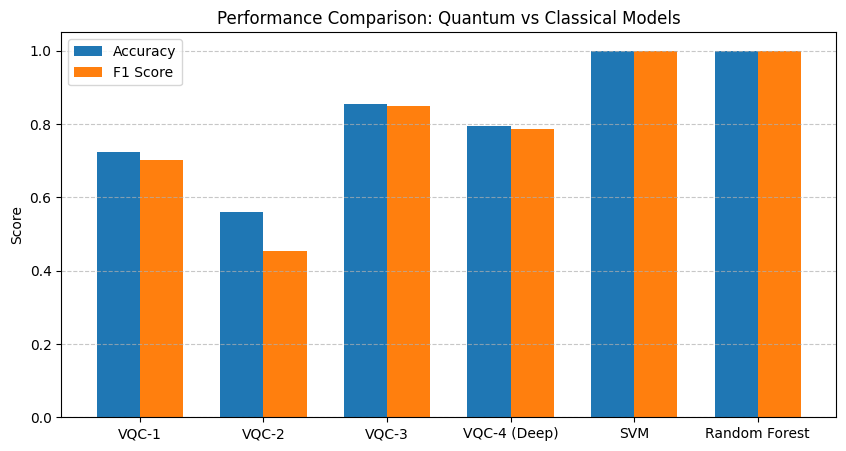

In [29]:
import pandas as pd
import numpy as np # Import numpy for np.arange
import matplotlib.pyplot as plt # Import matplotlib for plotting

# Aggregate results
model_names = ["VQC-1", "VQC-2", "VQC-3", "VQC-4 (Deep)", "SVM", "Random Forest"]
accuracies = [acc_1, acc_2, acc_3, acc_4, acc_svm, acc_rf]
f1_scores = [f1_1, f1_2, f1_3, f1_4, f1_svm, f1_rf]

# Bar plot comparison
x = np.arange(len(model_names))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, accuracies, width, label='Accuracy')
plt.bar(x + width/2, f1_scores, width, label='F1 Score')
plt.xticks(x, model_names)
plt.ylabel("Score")
plt.title("Performance Comparison: Quantum vs Classical Models")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

plot_path = RESULTS_DIR / "Performance-comparison-of-all-models.png"
# plt.savefig(plot_path, dpi=300, bbox_inches='tight')

plt.show()

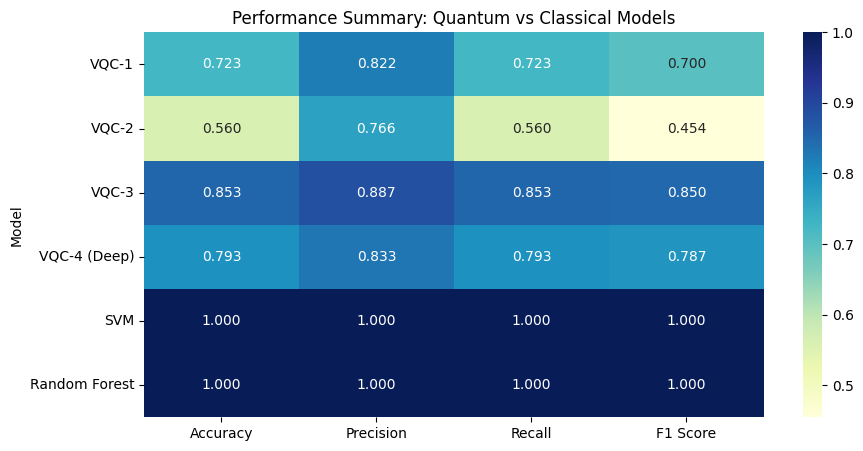

In [30]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Re-create summary_df as it's needed for this plot
# Assuming model_names, accuracies, prec_1, rec_1, f1_1, etc. are defined from previous cells
model_names = ["VQC-1", "VQC-2", "VQC-3", "VQC-4 (Deep)", "SVM", "Random Forest"]

# Aggregate results - ensure all are available from previous executions
accuracies = [acc_1, acc_2, acc_3, acc_4, acc_svm, acc_rf]
precisions = [prec_1, prec_2, prec_3, prec_4, prec_svm, prec_rf]
recalls = [rec_1, rec_2, rec_3, rec_4, rec_svm, rec_rf]
f1_scores = [f1_1, f1_2, f1_3, f1_4, f1_svm, f1_rf]

summary_df = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracies,
    'Precision': precisions,
    'Recall': recalls,
    'F1 Score': f1_scores
})

summary_df.set_index('Model', inplace=True)

plt.figure(figsize=(10, 5))
sns.heatmap(summary_df, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("Performance Summary: Quantum vs Classical Models")

plot_path = RESULTS_DIR / "Performance-summary-of-all-models.png"
# plt.savefig(plot_path, dpi=300, bbox_inches='tight')

plt.show()
